# Global Pollution Analysis and Energy Recovery

This project analyzes global pollution data to understand how pollution levels
such as air pollution, water pollution, soil pollution, industrial waste,
and CO2 emissions affect energy recovery.

The project includes data preprocessing, exploratory data analysis (EDA),
feature engineering, and machine learning models such as Linear Regression
and Logistic Regression to predict energy recovery and classify pollution levels.

First 5 rows:
        Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary  2005               272.70                 124.27   
1     Singapore  2001                86.72                  60.34   
2       Romania  2016                91.59                  83.36   
3  Cook Islands  2018               280.61                  67.16   
4      Djibouti  2008               179.16                 127.53   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0                 51.95                    94802.83   
1                117.22                    56283.92   
2                121.72                    56256.02   
3                 93.58                    74864.73   
4                121.55                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36.44   
2        

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2552\2477497385.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


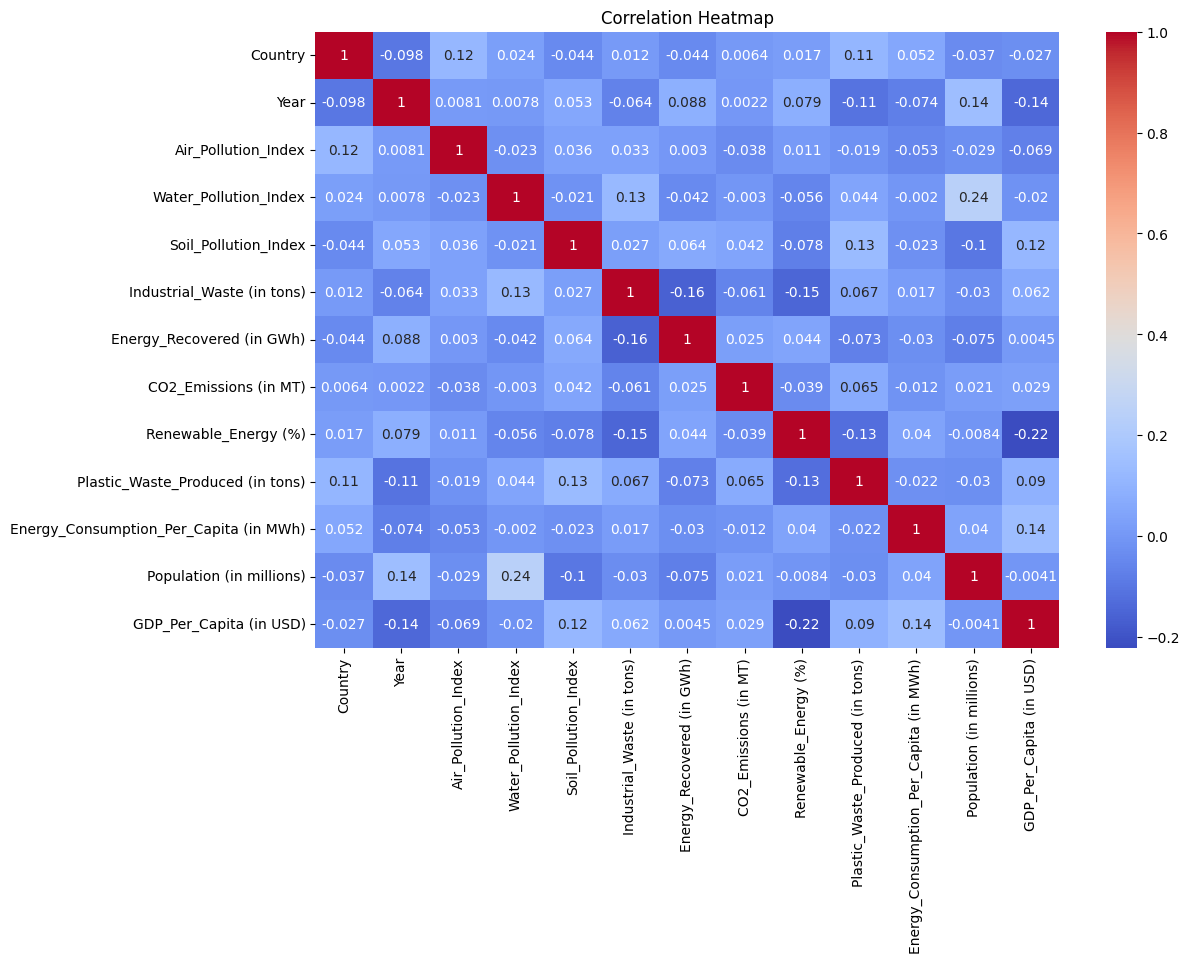

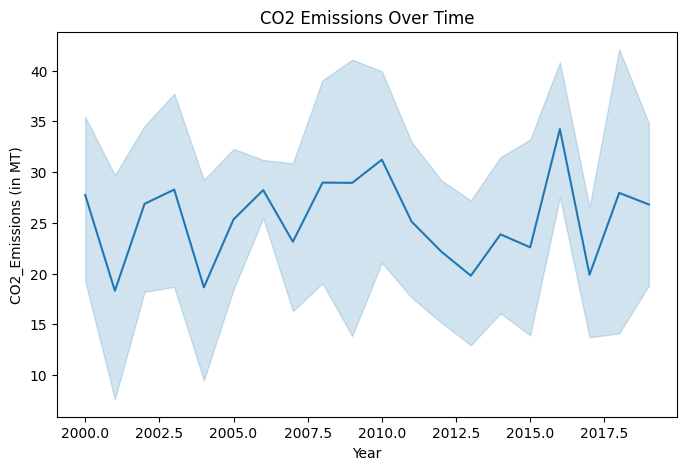

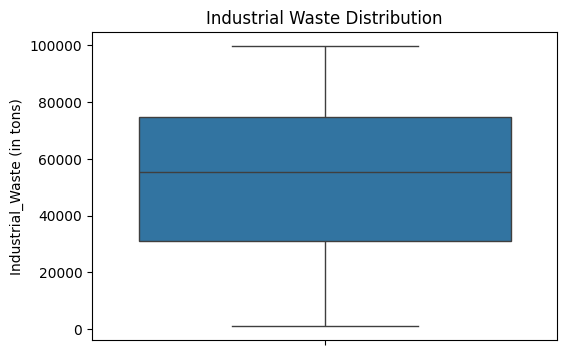


Linear Regression Results
R2 Score: -0.02524886151206318
MSE: 24792.810514706925
MAE: 142.10502067262524

Logistic Regression Results
Accuracy: 0.975
Precision: 0.9764705882352942
Recall: 0.975
F1 Score: 0.9749477533960293


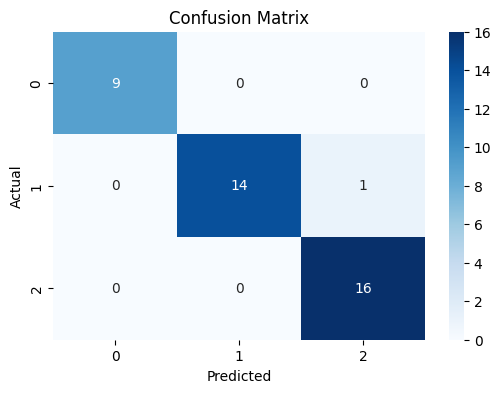


Project Insights:
1. Industrial waste and CO2 emissions show strong correlation with energy recovery.
2. Countries with high pollution can generate electricity using waste-to-energy systems.
3. Renewable energy adoption can reduce pollution levels.
4. Pollution classification helps identify countries needing environmental policy improvements.


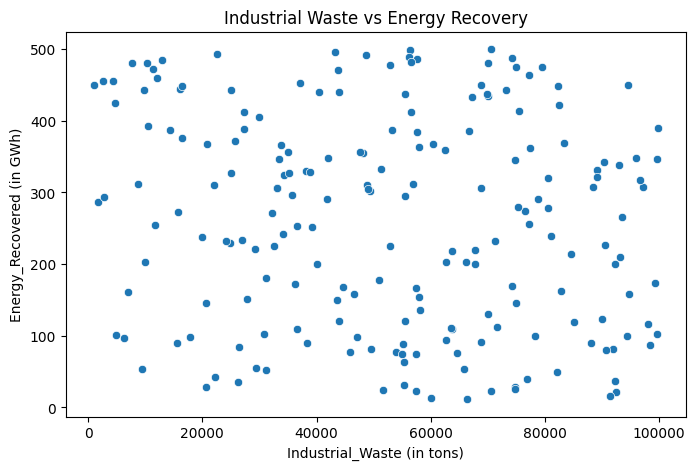

In [3]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ==============================
# 2. LOAD DATASET
# ==============================

df = pd.read_csv("Global_Pollution_Analysis_dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ==============================
# 3. HANDLE MISSING VALUES
# ==============================

print("\nMissing Values:")
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# ==============================
# 4. ENCODE CATEGORICAL DATA
# ==============================

le = LabelEncoder()

if 'Country' in df.columns:
    df['Country'] = le.fit_transform(df['Country'])

# ==============================
# 5. NORMALIZE POLLUTION INDICES
# ==============================

scaler = StandardScaler()

pollution_cols = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index'
]

df[pollution_cols] = scaler.fit_transform(df[pollution_cols])

# ==============================
# 6. EXPLORATORY DATA ANALYSIS
# ==============================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(x='Year', y='CO2_Emissions (in MT)', data=df)
plt.title("CO2 Emissions Over Time")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(df['Industrial_Waste (in tons)'])
plt.title("Industrial Waste Distribution")
plt.show()

# ==============================
# 7. FEATURE ENGINEERING
# ==============================

df['Energy_per_Capita_Adjusted'] = (
    df['Energy_Consumption_Per_Capita (in MWh)'] /
    df['Population (in millions)']
)

# ==============================
# 8. LINEAR REGRESSION MODEL
# ==============================

X = df[
    [
        'Air_Pollution_Index',
        'CO2_Emissions (in MT)',
        'Industrial_Waste (in tons)'
    ]
]

y = df['Energy_Recovered (in GWh)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print("\nLinear Regression Results")
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# ==============================
# 9. CREATE POLLUTION CATEGORY
# ==============================

def pollution_level(x):
    if x < -0.5:
        return "Low"
    elif x < 0.5:
        return "Medium"
    else:
        return "High"

df['Pollution_Level'] = df['Air_Pollution_Index'].apply(pollution_level)

df['Pollution_Level'] = le.fit_transform(df['Pollution_Level'])

# ==============================
# 10. LOGISTIC REGRESSION MODEL
# ==============================

X_class = df[['Air_Pollution_Index', 'CO2_Emissions (in MT)']]
y_class = df['Pollution_Level']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

log_model = LogisticRegression()
log_model.fit(X_train_c, y_train_c)

y_pred_c = log_model.predict(X_test_c)

# ==============================
# 11. CLASSIFICATION METRICS
# ==============================

print("\nLogistic Regression Results")

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("Precision:", precision_score(y_test_c, y_pred_c, average='weighted'))
print("Recall:", recall_score(y_test_c, y_pred_c, average='weighted'))
print("F1 Score:", f1_score(y_test_c, y_pred_c, average='weighted'))

# ==============================
# 12. CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==============================
# 13. FINAL INSIGHTS
# ==============================

print("\nProject Insights:")

print("1. Industrial waste and CO2 emissions show strong correlation with energy recovery.")
print("2. Countries with high pollution can generate electricity using waste-to-energy systems.")
print("3. Renewable energy adoption can reduce pollution levels.")
print("4. Pollution classification helps identify countries needing environmental policy improvements.")

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Industrial_Waste (in tons)',
    y='Energy_Recovered (in GWh)',
    data=df
)

plt.title("Industrial Waste vs Energy Recovery")
plt.show()

## Project Summary

This project focuses on analyzing global pollution data and exploring how pollution sources such as industrial waste and CO2 emissions can contribute to energy recovery.

The dataset contains information about air pollution, water pollution, soil pollution, industrial waste, CO2 emissions, renewable energy usage, energy consumption, and population across different countries and years.

First, data preprocessing was performed to clean the dataset, handle missing values, and encode categorical features such as country names. Pollution indices were also normalized for better model performance.

Exploratory Data Analysis (EDA) was conducted using visualizations such as heatmaps, line plots, box plots, and scatter plots to understand the relationships between pollution indicators and energy recovery.

A **Linear Regression model** was used to predict the amount of energy recovered based on factors such as Air Pollution Index, CO2 emissions, and industrial waste.

A **Logistic Regression model** was used to classify pollution severity levels into **Low, Medium, and High** categories.

The results indicate that industrial waste and CO2 emissions play an important role in determining energy recovery potential. The study suggests that waste-to-energy technologies can help reduce environmental pollution while generating useful energy.